   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.8 MB/s eta 0:00:00

===== TRAINING FOLD 1 =====
Epoch 1/50
3809/3809 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - accuracy: 0.7094 - loss: 0.8633 - val_accuracy: 0.8522 - val_loss: 0.4364
Epoch 2/50
3809/3809 ━━━━━━━━━━━━━━━━━━━━ 76s 12ms/step - accuracy: 0.8633 - loss: 0.4093 - val_accuracy: 0.9161 - val_loss: 0.2577
Epoch 3/50
3809/3809 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - accuracy: 0.9315 - loss: 0.2075 - val_accuracy: 0.9269 - val_loss: 0.2004
Epoch 4/50
3809/3809 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - accuracy: 0.9437 - loss: 0.1647 - val_accuracy: 0.9265 - val_loss: 0.2078
Epoch 5/50
3809/3809 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.9483 - loss: 0.1467 - val_accuracy: 0.9424 - val_loss: 0.1633
Epoch 6/50
3809/3809 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.9527 - loss: 0.1308 - val_accuracy: 0.9492 - val_loss: 0.1431
Epoch 7/50
3809/3809 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - accuracy: 0.9561 - loss: 0.1202 - val_accu

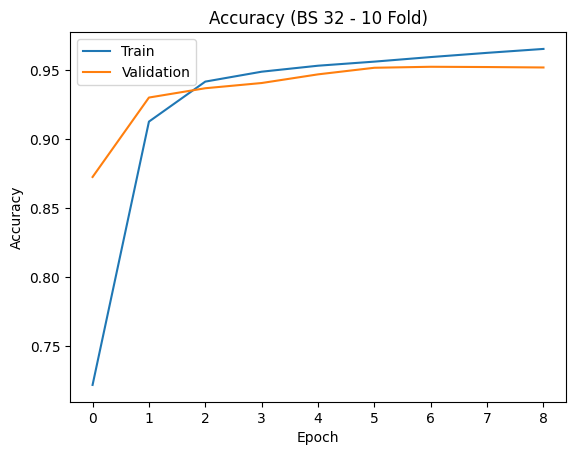

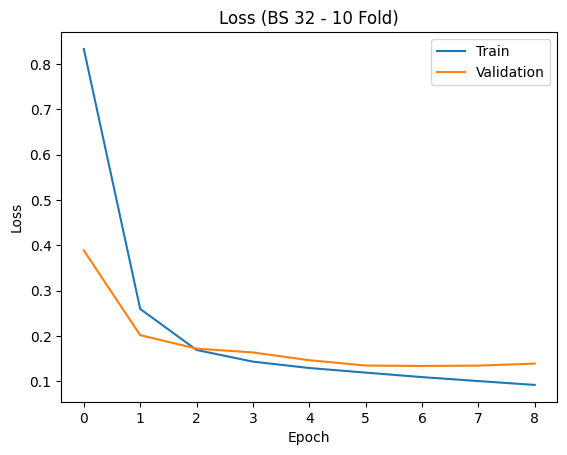

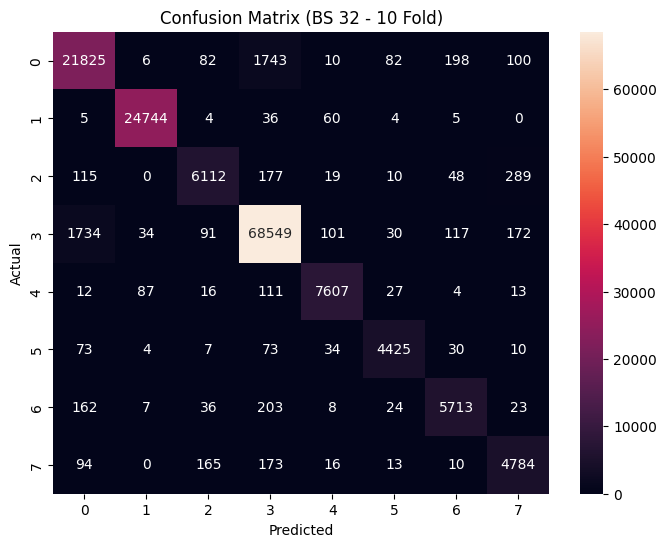

In [ ]:
# =========================
# 1. IMPORT
# =========================
!pip install gensim

import numpy as np
import pandas as pd
import ast
import pickle

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from gensim.models import Word2Vec

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/SKRIPSI/dataset_preprocessed.csv')

X_text = df['processed_text'].astype(str).values
X_tokens = df['tokens'].apply(ast.literal_eval).values
y = df['label'].values


# =========================
# 3. LOAD WORD2VEC
# =========================
w2v_model = Word2Vec.load("/content/drive/MyDrive/SKRIPSI/word2vec_skipgram.model")

EMBEDDING_DIM = 100
MAX_LEN = 200
MAX_VOCAB = 50000


# =========================
# 4. MODEL FUNCTION
# =========================
def create_model(vocab_size, embedding_matrix, num_classes):

    model = Sequential()

    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ))

    model.add(LSTM(128))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =========================
# 5. PARAMETER (BEST SCENARIO)
# =========================
batch_size = 32
n_splits = 10
EPOCHS = 50   # lebih aman GPU
num_classes = len(set(y))


# =========================
# 6. K-FOLD
# =========================
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

all_y_test = []
all_y_pred = []
all_history = []

fold_no = 1


for train_idx, test_idx in kfold.split(X_text):

    print(f"\n===== TRAINING FOLD {fold_no} =====")

    X_train_text = X_text[train_idx]
    X_test_text  = X_text[test_idx]

    y_train = y[train_idx]
    y_test  = y[test_idx]

    # Tokenizer
    tokenizer = Tokenizer(num_words=MAX_VOCAB)
    tokenizer.fit_on_texts(X_train_text)

    X_train_seq = tokenizer.texts_to_sequences(X_train_text)
    X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

    X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
    X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post')

    # Embedding Matrix
    word_index = tokenizer.word_index
    vocab_size = min(MAX_VOCAB, len(word_index) + 1)

    embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

    for word, i in word_index.items():
        if i < vocab_size and word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]

    # Model
    model = create_model(vocab_size, embedding_matrix, num_classes)

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Training
    history = model.fit(
        X_train_pad,
        y_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    all_history.append(history.history)

    # Predict
    y_pred = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_pred, axis=1)

    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)

    fold_no += 1


# =========================
# 7. EVALUASI
# =========================
acc = accuracy_score(all_y_test, all_y_pred)
prec = precision_score(all_y_test, all_y_pred, average='weighted')
rec = recall_score(all_y_test, all_y_pred, average='weighted')
f1 = f1_score(all_y_test, all_y_pred, average='weighted')

print("\n===== HASIL AKHIR =====")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)


# =========================
# 8. GRAFIK
# =========================
acc_hist = [h['accuracy'] for h in all_history]
val_acc_hist = [h['val_accuracy'] for h in all_history]
loss_hist = [h['loss'] for h in all_history]
val_loss_hist = [h['val_loss'] for h in all_history]

min_len = min(len(a) for a in acc_hist)

acc_mean = np.mean([a[:min_len] for a in acc_hist], axis=0)
val_acc_mean = np.mean([a[:min_len] for a in val_acc_hist], axis=0)
loss_mean = np.mean([l[:min_len] for l in loss_hist], axis=0)
val_loss_mean = np.mean([l[:min_len] for l in val_loss_hist], axis=0)

plt.figure()
plt.plot(acc_mean)
plt.plot(val_acc_mean)
plt.title("Accuracy (BS 32 - 10 Fold)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(loss_mean)
plt.plot(val_loss_mean)
plt.title("Loss (BS 32 - 10 Fold)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()


# =========================
# 9. CONFUSION MATRIX
# =========================
cm = confusion_matrix(all_y_test, all_y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (BS 32 - 10 Fold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =========================
# 10. SIMPAN HASIL
# =========================
with open('/content/drive/MyDrive/hasil_final.pkl', 'wb') as f:
    pickle.dump({
        "y_test": all_y_test,
        "y_pred": all_y_pred,
        "history": all_history
    }, f)

In [ ]:
from sklearn.metrics import classification_report
# =========================
# 9.1 METRIK PER KELAS
# =========================

class_names = [
    "Bisnis Ekonomi",
    "Bola",
    "Lifestyle",
    "Nasional",
    "Olahraga",
    "Otomotif",
    "Teknologi",
    "Travel"
]

report = classification_report(
    all_y_test,
    all_y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("\n===== METRIK PER KELAS =====")
report_df = pd.DataFrame(report).transpose()
print(report_df)


===== METRIK PER KELAS =====
                precision    recall  f1-score        support
Bisnis Ekonomi   0.908618  0.907635  0.908126   24046.000000
Bola             0.994454  0.995414  0.994934   24858.000000
Lifestyle        0.938431  0.902806  0.920274    6770.000000
Nasional         0.964596  0.967823  0.966207   70828.000000
Olahraga         0.968428  0.965723  0.967073    7877.000000
Otomotif         0.958830  0.950387  0.954590    4656.000000
Teknologi        0.932735  0.925032  0.928868    6176.000000
Travel           0.887405  0.910371  0.898741    5255.000000
accuracy         0.955425  0.955425  0.955425       0.955425
macro avg        0.944187  0.940649  0.942352  150466.000000
weighted avg     0.955424  0.955425  0.955401  150466.000000


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# =========================
# 9.1 METRIK PER KELAS
# =========================

class_names = [
    "Bisnis Ekonomi",
    "Bola",
    "Lifestyle",
    "Nasional",
    "Olahraga",
    "Otomotif",
    "Teknologi",
    "Travel"
]

# Classification report
report = classification_report(
    all_y_test,
    all_y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# =========================
# HITUNG ACCURACY PER KELAS
# =========================

cm = confusion_matrix(all_y_test, all_y_pred)

accuracy_per_class = []

total = np.sum(cm)

for i in range(len(class_names)):

    TP = cm[i, i]

    FP = np.sum(cm[:, i]) - TP

    FN = np.sum(cm[i, :]) - TP

    TN = total - (TP + FP + FN)

    acc = (TP + TN) / total

    accuracy_per_class.append(round(acc, 4))

# Tambahkan ke dataframe
report_df = report_df.iloc[:-3]   # hapus accuracy/global avg sementara
report_df["accuracy"] = accuracy_per_class

# Rapikan
report_df = report_df[[
    "accuracy",
    "precision",
    "recall",
    "f1-score",
    "support"
]]

report_df = report_df.round(4)

print("\n===== METRIK PER KELAS =====")
print(report_df)


===== METRIK PER KELAS =====
                accuracy  precision  recall  f1-score  support
Bisnis Ekonomi    0.9707     0.9086  0.9076    0.9081  24046.0
Bola              0.9983     0.9945  0.9954    0.9949  24858.0
Lifestyle         0.9930     0.9384  0.9028    0.9203   6770.0
Nasional          0.9681     0.9646  0.9678    0.9662  70828.0
Olahraga          0.9966     0.9684  0.9657    0.9671   7877.0
Otomotif          0.9972     0.9588  0.9504    0.9546   4656.0
Teknologi         0.9942     0.9327  0.9250    0.9289   6176.0
Travel            0.9928     0.8874  0.9104    0.8987   5255.0
